# Phase 4 · Medallion + dbt — tầng 6 của lakehouse

Hết Phase 3, bạn có đủ ba mảnh của một lakehouse: **MinIO** (chứa file), **Delta**
(bảng có giao dịch), **Spark** (tính toán). Nhưng logic biến đổi dữ liệu vẫn nằm rải
rác trong các cell notebook. Thử trả lời ba câu này về `03_spark.ipynb`:

- Bảng `gold_borough` được tính từ đâu, qua mấy bước?
- Nếu đổi bộ lọc ở giữa, những bảng nào phải dựng lại?
- Làm sao biết kết quả hôm nay có đúng không?

Không câu nào trả lời được. Đó không phải lỗi của bạn — đó là **giới hạn của notebook
như một công cụ sản xuất**. Notebook tuyệt vời để khám phá, và tệ hại để vận hành:
thứ tự chạy phụ thuộc người bấm chuột, không ai test được, không ai biết cái gì phụ
thuộc cái gì.

Phase 4 chuyển toàn bộ logic đó sang **dbt**, và sắp xếp theo kiến trúc **medallion**.

```
  raw/            bronze              silver               gold
  ────────        ──────────          ────────────────     ────────────
  Parquet    →    nguyên trạng   →    sạch, đúng kiểu  →   trả lời câu hỏi
  của TLC         + 3 cột metadata    1 dòng = 1 chuyến    đã tổng hợp

  41.169.720      41.169.720          35.613.229           80.523 + 1.300

  script ingest   ─────────── dbt lo từ đây trở đi ──────────────►
```

**Ranh giới quan trọng nhất của phase này:** dbt **không** nạp dữ liệu. Chữ T trong
ELT — Transform. Việc kéo file từ ngoài vào (E/L) thuộc về công cụ khác. Trộn hai
việc là lỗi kiến trúc thường gặp, và nó phá luôn khả năng test: dbt không test nổi
thứ nó tự nạp.

### Stack sau Phase 4

```
jupyter ──sc://15002──┐
  (notebook này)      ├──► spark-connect (DRIVER) ──► master ──► 2 worker
dbt   ──sc://15002────┘            │                                │
  (container riêng)          Hive Metastore                     s3a://
                             (Derby, volume)                     minio
```

**Hai client, một driver.** dbt và notebook nói chuyện với đúng một Spark, dùng chung
một catalog. Bảng dbt vừa tạo, notebook thấy ngay — không đồng bộ gì cả.

> **Cách học:** lệnh `dbt` gõ ở **terminal** (`make dbt`), notebook này để **nhìn kết
> quả và đo**. Đó cũng đúng cách làm việc thật: dbt là công cụ dòng lệnh, không phải
> thư viện Python bạn import.

## Chuẩn bị

In [1]:
import os, json, pathlib, textwrap
from pyspark.sql import SparkSession, functions as F

BUCKET = os.environ['LAKEHOUSE_BUCKET']
DBT    = pathlib.Path('/home/jovyan/dbt')      # mã nguồn dbt, mount chỉ-đọc

spark = SparkSession.builder.remote(os.environ['SPARK_REMOTE']).getOrCreate()

def sql(q, n=20, truncate=False):
    return spark.sql(q).show(n, truncate)

def dem(bang):
    return spark.table(bang).count()

print('Spark Connect:', os.environ['SPARK_REMOTE'])
print('Catalog      :', spark.conf.get('spark.sql.catalogImplementation'))
print('Warehouse    :', spark.conf.get('spark.sql.warehouse.dir'))

Spark Connect: sc://spark-connect:15002
Catalog      : hive
Warehouse    : s3a://lakehouse/warehouse


---
## Bước 1 · Thứ mới xuất hiện ở Phase 4: bảng có **tên**

Suốt Phase 2 và 3, mọi bảng đều gọi bằng **đường dẫn**:

```python
spark.read.format('delta').load('s3a://lakehouse/phase3/gold_borough')
```

Cách đó chạy được, nhưng có ba lỗ hổng chí mạng khi nhiều người cùng làm: ai cũng
phải thuộc đường dẫn, không ai biết hệ thống **có những bảng nào**, và không câu lệnh
nào hỏi được *"bảng này đã tồn tại chưa?"* — thiếu đúng câu hỏi đó thì **không thể có
model incremental**.

Thứ vá lỗ hổng này gọi là **catalog**. Từ Phase 4, `spark-defaults.conf` bật:

```
spark.sql.catalogImplementation   hive
```

`hive` ở đây **không phải** Hive engine (thứ đã chết từ lâu) mà là Hive *Metastore* —
chỉ là một schema SQL lưu metadata bảng. Ta dùng bản nhúng ghi vào Derby trên volume.

**Đây là đồ tạm, và cố ý tạm.** Phase 6 sẽ thay bằng Unity Catalog. Chính lúc thay bạn
mới thấy rõ Metastore thiếu gì mà UC có: phân quyền, lineage, tên ba tầng, nhiều engine
cùng đọc một catalog.

In [2]:
sql('show databases')

+---------+
|namespace|
+---------+
|bronze   |
|default  |
|gold     |
|probe_db |
|sandbox  |
|silver   |
+---------+



In [3]:
for db in ['bronze', 'silver', 'gold']:
    print(f'── {db} ' + '─' * 46)
    sql(f'show tables in {db}')

── bronze ──────────────────────────────────────────────
+---------+------------+-----------+
|namespace|tableName   |isTemporary|
+---------+------------+-----------+
|bronze   |yellow_trips|false      |
+---------+------------+-----------+

── silver ──────────────────────────────────────────────
+---------+------------+-----------+
|namespace|tableName   |isTemporary|
+---------+------------+-----------+
|silver   |silver_trips|false      |
|silver   |silver_zones|false      |
|silver   |taxi_zones  |false      |
+---------+------------+-----------+

── gold ──────────────────────────────────────────────
+---------+-----------------------+-----------+
|namespace|tableName              |isTemporary|
+---------+-----------------------+-----------+
|gold     |gold_daily_zone_revenue|false      |
|gold     |gold_hourly_demand     |false      |
+---------+-----------------------+-----------+



### Managed hay external? Câu hỏi phỏng vấn, và câu trả lời nằm ngay đây

Xem `Type` và `Location` của hai bảng dưới. Chúng khác loại, và khác biệt đó **quyết
định chuyện gì xảy ra khi bạn gõ `DROP TABLE`**.

In [4]:
print('╔═ silver_trips — dbt có khai location_root → EXTERNAL')
sql('describe extended silver.silver_trips', 60)

╔═ silver_trips — dbt có khai location_root → EXTERNAL


+----------------------------+---------------------------------------------------+-------+
|col_name                    |data_type                                          |comment|
+----------------------------+---------------------------------------------------+-------+
|trip_id                     |string                                             |NULL   |
|vendor_id                   |int                                                |NULL   |
|pickup_at                   |timestamp                                          |NULL   |
|dropoff_at                  |timestamp                                          |NULL   |
|pickup_zone_id              |int                                                |NULL   |
|dropoff_zone_id             |int                                                |NULL   |
|passenger_count             |int                                                |NULL   |
|trip_miles                  |double                                             |NULL   |

In [5]:
print('╔═ taxi_zones (seed) — không khai location → MANAGED')
sql('describe extended silver.taxi_zones', 60)

╔═ taxi_zones (seed) — không khai location → MANAGED
+----------------------------+---------------------------------------------------+-------+
|col_name                    |data_type                                          |comment|
+----------------------------+---------------------------------------------------+-------+
|LocationID                  |int                                                |NULL   |
|Borough                     |string                                             |NULL   |
|Zone                        |string                                             |NULL   |
|service_zone                |string                                             |NULL   |
|                            |                                                   |       |
|# Detailed Table Information|                                                   |       |
|Name                        |spark_catalog.silver.taxi_zones                    |       |
|Type                        |MANAGED

|  | managed | external |
|---|---|---|
| Ai sở hữu file? | metastore | bạn |
| `DROP TABLE` xoá file? | **có** | **không** |
| Đổi chỗ lưu được? | không | có |

Khác biệt này đã cắn thật một lần khi dựng phase này. Seed `taxi_zones` ban đầu được
khai `location_root` như mọi model khác. dbt nạp lại seed bằng `DROP TABLE` rồi
`CREATE TABLE` — với bảng external, `DROP` chỉ xoá phần khai báo, **file trên MinIO
còn nguyên**. Câu `CREATE` ngay sau đó trỏ lại thư mục cũ, nhận vơ dữ liệu cũ, rồi
chèn thêm một bộ nữa.

Kết quả: 265 dòng thành **530**, bài test `unique` trên `zone_id` đỏ đúng 265 dòng.
Cách chữa nằm trong `dbt/dbt_project.yml`: bỏ `location_root` khỏi khối `seeds` để
bảng thành managed.

---
## Bước 2 · Bronze — và bằng chứng vì sao phải có silver

Quy tắc của bronze chỉ có một: **chép nguyên trạng**. Không đổi tên cột, không ép kiểu,
không lọc dòng rác. Chỉ được thêm cột metadata bắt đầu bằng `_`.

Nghe lười biếng. Thực ra đó là điều khiến bronze có giá trị: nó là bản sao **đối chiếu
được với nguồn**. Ngày nào silver ra số lạ, bạn cần một chỗ chắc chắn chưa ai đụng vào
để lần ngược.

Nhìn ba cột `_` mà `scripts/ingest_bronze.py` thêm vào — và nhìn luôn tên cột gốc:
`VendorID`, `tpep_pickup_datetime`, `PULocationID`. Xấu, không nhất quán, và bronze
**không được phép sửa**.

In [6]:
sql('select * from bronze.yellow_trips limit 3', 3, True)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------------+--------------------+-------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|        _source_file|        _ingested_at|_pickup_month|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------------+--------------------+-------------+
|       2| 2024-02-

In [7]:
tong = dem('bronze.yellow_trips')
print(f'bronze.yellow_trips: {tong:,} dòng\n')
sql('select _pickup_month, count(*) as so_dong, min(_ingested_at) as nap_luc '
    'from bronze.yellow_trips group by 1 order by 1', 12)

bronze.yellow_trips: 41,169,720 dòng



+-------------+-------+--------------------------+
|_pickup_month|so_dong|nap_luc                   |
+-------------+-------+--------------------------+
|2024-01      |2964624|2026-08-23 23:23:37.496473|
|2024-02      |3007526|2026-08-23 23:23:52.375432|
|2024-03      |3582628|2026-08-23 23:24:58.086691|
|2024-04      |3514289|2026-08-23 23:24:02.972159|
|2024-05      |3723833|2026-08-23 23:24:07.55155 |
|2024-06      |3539193|2026-08-23 23:24:12.450403|
|2024-07      |3076903|2026-08-23 23:24:17.169105|
|2024-08      |2979183|2026-08-23 23:24:21.859867|
|2024-09      |3633030|2026-08-23 23:24:26.618896|
|2024-10      |3833771|2026-08-23 23:24:31.563899|
|2024-11      |3646369|2026-08-23 23:24:36.82704 |
|2024-12      |3668371|2026-08-23 23:24:45.191488|
+-------------+-------+--------------------------+



### Tổng điều tra chất lượng dữ liệu

Trước khi viết một dòng bộ lọc nào, hãy **đếm xem có bao nhiêu rác**. Đây là việc đầu
tiên của một data engineer khi nhận dataset lạ — cũng là việc người ta hay bỏ qua rồi
trả giá ba tháng sau.

Mỗi con số dưới đây tương ứng đúng một dòng `where` trong `models/silver/silver_trips.sql`.

In [8]:
kiem_tra = [
    ('Ngày đón ngoài năm 2024',   "tpep_pickup_datetime < '2024-01-01' or tpep_pickup_datetime >= '2025-01-01'"),
    ('Trả khách TRƯỚC khi đón',   'tpep_dropoff_datetime <= tpep_pickup_datetime'),
    ('Quãng đường = 0 dặm',       'trip_distance <= 0'),
    ('Quãng đường > 500 dặm',     'trip_distance > 500'),
    ('Giá cước ÂM',               'fare_amount < 0'),
    ('Tổng tiền ÂM',              'total_amount < 0'),
    ('Số khách = 0 hoặc NULL',    'passenger_count is null or passenger_count <= 0'),
    ('Mã vùng ngoài 1..265',      'PULocationID not between 1 and 265 or DOLocationID not between 1 and 265'),
    ('Chuyến dài hơn 12 tiếng',   'unix_timestamp(tpep_dropoff_datetime) - unix_timestamp(tpep_pickup_datetime) > 12*3600'),
]

dk = ',\n'.join(f'  sum(case when {c} then 1 else 0 end) as `{ten}`' for ten, c in kiem_tra)
row = spark.sql(f'select\n{dk}\nfrom bronze.yellow_trips').collect()[0].asDict()

print(f"{'Vấn đề':<30} {'Số dòng':>12}  {'% tổng':>7}")
print('─' * 54)
for ten, n in row.items():
    print(f'{ten:<30} {n:>12,}  {n/tong*100:6.3f}%')
print('─' * 54)
print(f"{'TỔNG bronze':<30} {tong:>12,}")

Vấn đề                              Số dòng   % tổng
──────────────────────────────────────────────────────
Ngày đón ngoài năm 2024                  56   0.000%
Trả khách TRƯỚC khi đón              13,510   0.033%
Quãng đường = 0 dặm                 776,305   1.886%
Quãng đường > 500 dặm                 1,040   0.003%
Giá cước ÂM                         731,024   1.776%
Tổng tiền ÂM                        609,344   1.480%
Số khách = 0 hoặc NULL            4,492,586  10.912%
Mã vùng ngoài 1..265                      0   0.000%
Chuyến dài hơn 12 tiếng              19,723   0.048%
──────────────────────────────────────────────────────
TỔNG bronze                      41,169,720


In [9]:
silver = dem('silver.silver_trips')
print(f'bronze : {tong:>12,} dòng')
print(f'silver : {silver:>12,} dòng')
print(f'         {tong-silver:>12,} dòng bị loại  ({(tong-silver)/tong*100:.1f}%)')

bronze :   41,169,720 dòng
silver :   35,613,229 dòng
            5,556,491 dòng bị loại  (13.5%)


**Hơn 13% dữ liệu là rác.** Không phải con số bất thường — dữ liệu công khai thường
bẩn cỡ này, và dữ liệu doanh nghiệp chẳng sạch hơn. Vẽ dashboard thẳng từ bronze thì
một phần tám con số bạn trình bày là bịa.

Một điểm về triết lý: silver **LỌC**, không **SỬA**. Đoán xem một chuyến giá âm "đáng
lẽ" là bao nhiêu chính là bịa dữ liệu. Dòng bị loại vẫn nằm nguyên ở bronze — cần thì
mở ra xem, không mất đi đâu.

Chú ý dòng cuối bảng: **chuyến dài hơn 12 tiếng**. Bộ lọc `dropoff > pickup` KHÔNG bắt
được nó — một chuyến 30 tiếng vẫn thoả điều kiện đó. Bước 5 sẽ quay lại con số này.

---
## Bước 3 · Một model dbt thực chất là gì

Mở thẳng file. Không có phép màu nào cả — một model dbt là **một câu `SELECT` trong
file `.sql`**, cộng thêm vài chỗ chèn Jinja.

Điều dbt làm: đọc file, thay các hàm Jinja thành tên bảng thật, bọc câu `SELECT` vào
`CREATE TABLE` (hoặc `MERGE`), rồi gửi cho Spark. **dbt không tính toán gì** — nó là
một cỗ máy sinh SQL kèm một cỗ máy dựng đồ thị phụ thuộc.

In [10]:
print((DBT / 'models/gold/gold_hourly_demand.sql').read_text())

/*
  "Giờ nào đông khách nhất, ở quận nào?" — câu hỏi điều phối xe kinh điển.
  Bảng cực nhỏ (24 giờ × 7 thứ × 6 quận ≈ 1000 dòng) nhưng đủ vẽ heatmap.
*/

with trips as (
    select * from {{ ref('silver_trips') }}
),

zones as (
    select * from {{ ref('silver_zones') }}
)

select
    zones.borough,
    date_format(trips.pickup_at, 'EEEE')  as day_of_week,
    trips.pickup_hour,

    count(*)                              as trip_count,
    round(avg(trips.trip_miles), 2)       as avg_miles,
    round(sum(trips.total_amount), 2)     as revenue

from trips
left join zones on trips.pickup_zone_id = zones.zone_id
group by 1, 2, 3



Ba thứ Jinja đáng chú ý, chỉ ba thứ này thôi đã là 90% dbt:

| Cú pháp | Nghĩa | Vì sao quan trọng |
|---|---|---|
| `{{ ref('silver_trips') }}` | tên bảng của model khác | dbt **suy ra đồ thị phụ thuộc từ đây** |
| `{{ source('bronze', ...) }}` | bảng dbt không tạo, chỉ đọc | đánh dấu cửa vào của hệ thống |
| `{{ config(...) }}` | dựng bảng kiểu gì | table / view / incremental |

Câu quan trọng nhất là `ref`. Bạn **không bao giờ** viết tên bảng cứng trong dbt.
Nhờ vậy dbt biết `gold_hourly_demand` cần `silver_trips` chạy xong trước — và đó
chính là cách nó tự dựng ra thứ tự chạy. Bạn không xếp lịch, bạn khai báo quan hệ.

Giờ xem SQL **thật sự** được gửi cho Spark. dbt ghi nó ra `target/compiled/`:

In [11]:
compiled = DBT / 'target/compiled/lakehouse/models/gold/gold_hourly_demand.sql'
print(compiled.read_text())

/*
  "Giờ nào đông khách nhất, ở quận nào?" — câu hỏi điều phối xe kinh điển.
  Bảng cực nhỏ (24 giờ × 7 thứ × 6 quận ≈ 1000 dòng) nhưng đủ vẽ heatmap.
*/

with trips as (
    select * from silver.silver_trips
),

zones as (
    select * from silver.silver_zones
)

select
    zones.borough,
    date_format(trips.pickup_at, 'EEEE')  as day_of_week,
    trips.pickup_hour,

    count(*)                              as trip_count,
    round(avg(trips.trip_miles), 2)       as avg_miles,
    round(sum(trips.total_amount), 2)     as revenue

from trips
left join zones on trips.pickup_zone_id = zones.zone_id
group by 1, 2, 3


`{{ ref('silver_trips') }}` đã thành `silver.silver_trips`. Chỉ vậy thôi.

Còn `target/run/` chứa câu lệnh **hoàn chỉnh** kèm `create table` bao ngoài — thứ Spark
nhận cuối cùng. Đây là chỗ đáng nhớ nhất khi gỡ lỗi dbt: **đừng đoán dbt sinh ra gì,
mở file ra đọc.**

In [12]:
run_sql = (DBT / 'target/run/lakehouse/models/gold/gold_hourly_demand.sql').read_text()
print(run_sql[:700])


  
    
        create or replace table gold.gold_hourly_demand
      
      
    using delta
      
      
      
      
      
    location 's3a://lakehouse/phase4/gold/gold_hourly_demand'
      

      as
      /*
  "Giờ nào đông khách nhất, ở quận nào?" — câu hỏi điều phối xe kinh điển.
  Bảng cực nhỏ (24 giờ × 7 thứ × 6 quận ≈ 1000 dòng) nhưng đủ vẽ heatmap.
*/

with trips as (
    select * from silver.silver_trips
),

zones as (
    select * from silver.silver_zones
)

select
    zones.borough,
    date_format(trips.pickup_at, 'EEEE')  as day_of_week,
    trips.pickup_hour,

    count(*)                              as trip_count,
    round(avg(trips.trip_miles), 2)       as avg_miles


### Còn model incremental thì SQL trông khác hẳn

`silver_trips` khai `materialized='incremental'` + `strategy='merge'`. Xem dbt sinh
ra gì — chú ý câu `merge into`, và chú ý mệnh đề `when matched` / `when not matched`.
Đây đúng là câu `MERGE` của Delta đã học tay ở **bước 5 Phase 2**, nay do dbt viết hộ.

In [13]:
inc = (DBT / 'target/run/lakehouse/models/silver/silver_trips.sql').read_text()
i = inc.lower().find('merge')
print(inc[i-200:i+700] if i > 0 else inc[:900])

.trip_id
          

      when matched then update set
         * 

      when not matched then insert *



---
## Bước 4 · Chạy pipeline và đo cái phễu

Mở terminal, gõ:

```bash
make dbt          # = dbt build: seed → model → test, đúng thứ tự
```

`dbt build` khác `dbt run` ở chỗ nó **xen test vào giữa**: dựng xong model nào là test
model đó ngay, và nếu test đỏ thì **dừng luôn nhánh phía sau**. Nghĩa là dữ liệu bẩn
không kịp lan xuống gold. Thói quen đúng là luôn dùng `build`, không dùng `run`.

Thứ tự dbt tự tính ra từ đồ thị `ref`:

```
taxi_zones (seed)  ──►  silver_zones ──┐
                                       ├──►  gold_daily_zone_revenue
bronze.yellow_trips ──►  silver_trips ─┤
      (source)                         └──►  gold_hourly_demand
```

Chạy xong, quay lại đây đo cái phễu:

In [14]:
bang = ['bronze.yellow_trips', 'silver.silver_trips', 'silver.silver_zones',
        'gold.gold_daily_zone_revenue', 'gold.gold_hourly_demand']
so = {b: dem(b) for b in bang}
for b, n in so.items():
    print(f'{b:<32} {n:>12,}')

bronze.yellow_trips                41,169,720
silver.silver_trips                35,613,229
silver.silver_zones                       265
gold.gold_daily_zone_revenue           80,523
gold.gold_hourly_demand                 1,300


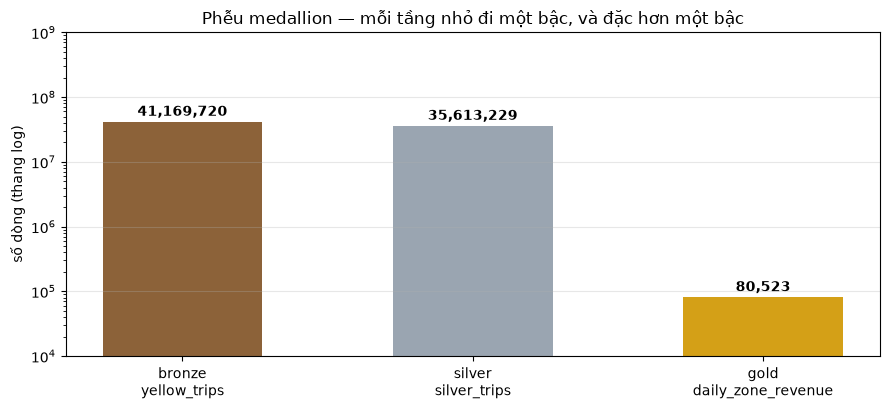

In [15]:
import matplotlib.pyplot as plt

nhan  = ['bronze\nyellow_trips', 'silver\nsilver_trips', 'gold\ndaily_zone_revenue']
giatri = [so['bronze.yellow_trips'], so['silver.silver_trips'], so['gold.gold_daily_zone_revenue']]

fig, ax = plt.subplots(figsize=(9, 4.2))
mau = ['#8c6239', '#9aa5b1', '#d4a017']
b = ax.bar(nhan, giatri, color=mau, width=0.55)
ax.set_yscale('log')
ax.set_ylabel('số dòng (thang log)')
ax.set_title('Phễu medallion — mỗi tầng nhỏ đi một bậc, và đặc hơn một bậc')
for r, v in zip(b, giatri):
    ax.text(r.get_x() + r.get_width()/2, v*1.25, f'{v:,}', ha='center', fontweight='bold')
ax.set_ylim(1e4, 1e9)
ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

Thang log là cố ý: nếu vẽ thang thường thì cột gold **biến mất** — 80 nghìn so với 41
triệu là 0,2%. Và đó chính là điểm của tầng gold: nó nhỏ tới mức dashboard vẽ tức thì,
trong khi vẫn trả lời đúng câu hỏi.

Hỏi một câu nghiệp vụ trên gold để thấy nó nhanh cỡ nào:

In [16]:
sql("""select borough, sum(trip_count) as chuyen, round(sum(revenue)/1e6, 1) as trieu_do,
        round(avg(card_tip_pct), 1) as ty_le_boa_the
        from gold.gold_daily_zone_revenue where borough is not null
        group by 1 order by 2 desc""".replace('\n', ' '), 10)

+-------------+--------+--------+-------------+
|borough      |chuyen  |trieu_do|ty_le_boa_the|
+-------------+--------+--------+-------------+
|Manhattan    |31645465|756.3   |20.8         |
|Queens       |3484435 |260.8   |9.3          |
|Brooklyn     |298924  |9.8     |5.8          |
|Unknown      |107092  |3.3     |21.9         |
|Bronx        |67588   |2.7     |1.2          |
|N/A          |7821    |0.7     |13.7         |
|EWR          |1224    |0.1     |14.6         |
|Staten Island|680     |0.0     |17.2         |
+-------------+--------+--------+-------------+



### Một cái bẫy nghiệp vụ giấu trong cột `card_tip_pct`

Cột tỷ lệ boa **chỉ** tính trên chuyến trả bằng thẻ. Lý do nằm ở dữ liệu, không nằm ở
kỹ thuật: chuyến trả tiền mặt **luôn ghi tip = 0**, vì tài xế bỏ túi và hệ thống không
thấy. Gộp chung hai loại là kéo tụt con số xuống rồi kết luận *"khách New York keo
kiệt"* — sai hoàn toàn.

Đây là kiểu lỗi **không công cụ nào bắt hộ**. dbt test không bắt, Spark không bắt,
kiểu dữ liệu không bắt. Chỉ người hiểu dữ liệu mới tránh được. Và đó là lý do vai trò
data engineer không thay bằng một cái script được.

In [17]:
sql("""select case payment_type_id when 1 then 'Thẻ' when 2 then 'Tiền mặt' else 'Khác' end as hinh_thuc,
        count(*) as chuyen, round(avg(tip_amount), 2) as boa_trung_binh,
        round(sum(case when tip_amount > 0 then 1 else 0 end) / count(*) * 100, 1) as pct_co_boa
        from silver.silver_trips group by 1 order by 2 desc""".replace('\n', ' '), 5)

+---------+--------+--------------+----------+
|hinh_thuc|chuyen  |boa_trung_binh|pct_co_boa|
+---------+--------+--------------+----------+
|Thẻ      |29860056|4.36          |94.4      |
|Tiền mặt |5216907 |0.0           |0.0       |
|Khác     |536266  |0.01          |0.1       |
+---------+--------+--------------+----------+



---
## Bước 5 · Test — thứ biến "chạy được" thành "tin được"

dbt có bốn loại test dựng sẵn, khai bằng YAML, mỗi cái một dòng. Đừng để vẻ tầm thường
đánh lừa: ba trong bốn bài test dưới đây **đã bắt được lỗi thật** khi dựng phase này.

| Test | Câu hỏi nó hỏi | Đã bắt được gì ở đây |
|---|---|---|
| `not_null` | cột này có thủng lỗ không? | — |
| `unique` | khoá có trùng không? | **4 dòng trùng** trong 36 triệu |
| `accepted_values` | có giá trị lạ không? | thiếu borough `Unknown` / `N/A` |
| `relationships` | khoá ngoại có mồ côi không? | **107.092 dòng** mồ côi |

Thêm một loại nữa quan trọng không kém: **singular test** — chỉ là một câu SQL trong
`tests/`, quy ước duy nhất là *trả về 0 dòng thì đậu*.

In [18]:
print((DBT / 'tests/assert_gold_matches_silver.sql').read_text())

/*
  TEST ĐƠN LẺ (singular test) — chỉ là một câu SQL, quy ước duy nhất:
  **trả về 0 dòng là ĐẬU, trả về dòng nào là RỚT.**
  Khác test kiểu `unique`/`not_null` ở chỗ nó diễn đạt được logic tuỳ ý.

  Đây là bài test đáng giá nhất trong dự án: ĐỐI CHIẾU. Tổng doanh thu ở gold
  phải bằng tổng doanh thu ở silver. Nếu một ngày nào đó ai đó thêm một mệnh đề
  join sai và làm nhân đôi dòng, mọi test not_null/unique vẫn xanh mướt —
  chỉ bài test này đỏ.

  "Số tổng ở tầng trên phải khớp tầng dưới" là dạng test mà kiểm toán viên và
  dân tài chính đòi đầu tiên. Biết viết nó là khác biệt giữa "chạy được dbt"
  và "tin được kết quả".
*/

with silver_total as (
    select sum(total_amount) as amount from {{ ref('silver_trips') }}
),

gold_total as (
    select sum(revenue) as amount from {{ ref('gold_daily_zone_revenue') }}
)

select
    silver_total.amount as silver_amount,
    gold_total.amount   as gold_amount,
    abs(silver_total.amount - gold_total.amount) as gap
from silver_total, gold_

Đây là bài test đáng giá nhất trong dự án: **đối chiếu tổng**. Nếu ai đó thêm một mệnh
đề join sai làm nhân đôi dòng, mọi test `not_null`/`unique` vẫn xanh mướt — chỉ bài
test này đỏ. "Số tổng ở tầng trên phải khớp tầng dưới" là thứ kiểm toán viên đòi đầu
tiên, và biết viết nó là khác biệt giữa *chạy được dbt* và *tin được kết quả*.

Tự kiểm chứng bằng tay:

In [19]:
a = spark.sql('select sum(total_amount) from silver.silver_trips').collect()[0][0]
b = spark.sql('select sum(revenue) from gold.gold_daily_zone_revenue').collect()[0][0]
print(f'silver : {a:>18,.2f} $')
print(f'gold   : {b:>18,.2f} $')
print(f'lệch   : {abs(a-b):>18,.2f} $   ← ngưỡng test là 1$ cho sai số làm tròn double')

silver :   1,033,634,348.08 $
gold   :   1,033,634,348.08 $
lệch   :               0.00 $   ← ngưỡng test là 1$ cho sai số làm tròn double


### Tự tay làm một bài test đỏ lên

Trần thời lượng chuyến để trong biến `max_trip_hours` chính là để tháo ra được. Ở
terminal, gõ:

```bash
docker compose exec -w /dbt dbt dbt build --select silver_trips+ --vars '{max_trip_hours: 999}'
```

Nới trần lên 999 giờ → những chuyến "quên tắt đồng hồ" lọt vào silver → bài test
`assert_trip_duration_sane` (ngưỡng cứng 12 giờ) đỏ **và gold bị chặn không cho dựng**.

Đó là toàn bộ giá trị của `dbt build`: dữ liệu bẩn dừng lại ở silver, không lan xuống
bảng mà analyst đang nhìn. Chạy xong nhớ dựng lại bản sạch:

```bash
make dbt
```

Số chuyến sẽ lọt thêm nếu nới trần — đếm trước cho biết:

In [20]:
n = spark.sql('select count(*) from bronze.yellow_trips where '
              'unix_timestamp(tpep_dropoff_datetime) - unix_timestamp(tpep_pickup_datetime) > 12*3600'
             ).collect()[0][0]
print(f'{n:,} chuyến dài hơn 12 tiếng đang bị chặn ở cửa silver')

19,723 chuyến dài hơn 12 tiếng đang bị chặn ở cửa silver


---
## Bước 6 · SAI CÓ CHỦ ĐÍCH — pipeline không idempotent

Đây là bước quan trọng nhất của Phase 4, và là cầu nối thẳng sang Phase 7.

**Idempotent** = chạy N lần cho kết quả y hệt chạy 1 lần. Nghe như chuyện hiển nhiên,
cho tới lúc bạn nhận ra pipeline được chạy lại **liên tục**: job lỗi giữa chừng,
Airflow tự retry, cần backfill ba tháng cũ, hoặc đơn giản là bấm nhầm hai lần.

`models/sandbox/sandbox_trips_append.sql` khác `silver_trips` đúng hai chỗ:

```
  silver_trips                    sandbox_trips_append
  ────────────────────────        ────────────────────────
  incremental_strategy = merge    incremental_strategy = append
  unique_key = 'trip_id'          (không có unique_key)
```

`append` trông vô hại, còn **nhanh hơn** merge vì khỏi dò xem dòng đã tồn tại chưa.
Rất nhiều pipeline ngoài đời được viết đúng như thế này.

Chạy nó **ba lần** ở terminal:

```bash
make dbt-trap
make dbt-trap
make dbt-trap
```

(`make dbt` thường **không** chạy thư mục `sandbox` — nếu chạy thì mỗi lần build
lại nhân đôi dữ liệu trong đó, đúng cái bẫy nó dùng để minh hoạ.)

Rồi đếm ở đây:

In [21]:
n_append = dem('sandbox.sandbox_trips_append')
mot_ngay = spark.sql("select count(*) from bronze.yellow_trips "
                     "where date(tpep_pickup_datetime) = '2024-01-15'").collect()[0][0]
print(f'Số chuyến thật ngày 2024-01-15 : {mot_ngay:>10,}')
print(f'Số dòng trong bảng append      : {n_append:>10,}')
print(f'                                 {n_append/mot_ngay:>10.1f} lần')

Số chuyến thật ngày 2024-01-15 :     77,033
Số dòng trong bảng append      :    231,099
                                        3.0 lần


Dữ liệu nhân lên theo số lần chạy. Và điểm đáng sợ nhất:

```
Done. PASS=1 WARN=0 ERROR=0 SKIP=0
```

**dbt báo thành công cả ba lần.** Không lỗi, không cảnh báo, không test mặc định nào
đỏ. Chỉ có doanh thu tự nhiên tăng gấp đôi, và ba tuần sau kế toán gọi điện.

Giờ làm điều ngược lại với model thật. Chạy `make dbt` thêm một lần nữa rồi đếm:

In [22]:
print(f'silver.silver_trips: {dem("silver.silver_trips"):,} dòng')
print('(chạy `make dbt` bao nhiêu lần con số này cũng không đổi)')

silver.silver_trips: 35,613,229 dòng
(chạy `make dbt` bao nhiêu lần con số này cũng không đổi)


### Vì sao merge đứng yên còn append phình ra

Mở `_delta_log` của bảng silver — đúng thói quen "đọc file thô" từ Phase 1. Mỗi lần
chạy lại sinh một version mới, nhưng nội dung bảng không đổi:

In [23]:
sql('describe history silver.silver_trips', 10, True)

+-------+-------------------+------+--------+--------------------+--------------------+----+--------+---------+-----------+--------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|userId|userName|           operation| operationParameters| job|notebook|clusterId|readVersion|isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+------+--------+--------------------+--------------------+----+--------+---------+-----------+--------------+-------------+--------------------+------------+--------------------+
|      3|2026-08-23 23:37:52|  NULL|    NULL|               MERGE|{predicate -> ["(...|NULL|    NULL|     NULL|          2|  Serializable|        false|{numTargetRowsCop...|        NULL|Apache-Spark/4.1....|
|      2|2026-08-23 23:36:09|  NULL|    NULL|CREATE OR REPLACE...|{partitionBy -> [...|NULL|    NULL|     NULL|          1|  Serializable|        false|{numFiles -> 804

Nhìn cột `operation`: lần đầu là `CREATE TABLE AS SELECT`, những lần sau là `MERGE`.
Mở `operationMetrics` của một dòng MERGE sẽ thấy `numTargetRowsInserted = 0` —
merge chạy, không chèn dòng nào, vì mọi `trip_id` đều đã có mặt.

Ba điều kiện để một pipeline idempotent, gộp lại từ cả phase này:

| Tầng | Cơ chế | Nằm ở đâu |
|---|---|---|
| ingest | `replaceWhere` theo tháng | `scripts/ingest_bronze.py` |
| silver | `MERGE` trên khoá duy nhất | `config(unique_key=...)` |
| gold | dựng lại toàn bộ (`table`) | `+materialized: table` |

Tầng gold dùng cách thô nhất — xoá đi dựng lại — và **đó là lựa chọn đúng**: bảng chỉ
80 nghìn dòng, dựng lại mất 15 giây, đổi lại là không bao giờ phải nghĩ về idempotency
ở tầng đó nữa. Tối ưu sớm ở chỗ không đáng là một dạng nợ kỹ thuật.

> Phase 7 (Airflow) sẽ dựng đúng ba cơ chế này thành DAG chạy hàng đêm có backfill.
> Nếu hôm nay bạn hiểu vì sao bảng append phình ra, Phase 7 sẽ nhẹ hơn nhiều.

---
## Bước 7 · Lineage — thứ notebook không bao giờ có

Sinh tài liệu:

```bash
make dbt-docs        # rồi mở http://localhost:8081
```

Bấm hình tròn xanh góc dưới bên phải để xem **sơ đồ lineage**. Đó là câu trả lời cho
ba câu hỏi mở đầu notebook này — thứ mà `03_spark.ipynb` không cách nào trả lời.

Điều đáng nói: **không ai vẽ sơ đồ đó cả**. dbt suy ra nó từ các câu `{{ ref() }}`
nằm rải rác trong model. Tài liệu không thể lỗi thời, vì nó được sinh ra từ chính mã
đang chạy. Sơ đồ vẽ tay trong Confluence thì sai từ tuần thứ hai.

Đọc thẳng đồ thị đó từ `manifest.json`:

In [24]:
mf = json.loads((DBT / 'target/manifest.json').read_text())
print(f"{'Node':<42} {'Kiểu':<13} phụ thuộc vào")
print('─' * 92)
for k, v in sorted(mf['nodes'].items()):
    if v['resource_type'] not in ('model', 'seed'):
        continue
    deps = [d.split('.')[-1] for d in v['depends_on'].get('nodes', [])]
    print(f"{v['name']:<42} {v['config']['materialized']:<13} {', '.join(deps) or '—'}")

Node                                       Kiểu          phụ thuộc vào
────────────────────────────────────────────────────────────────────────────────────────────
gold_daily_zone_revenue                    table         silver_trips, silver_zones
gold_hourly_demand                         table         silver_trips, silver_zones
sandbox_trips_append                       incremental   yellow_trips
silver_trips                               incremental   yellow_trips
silver_zones                               table         taxi_zones
taxi_zones                                 seed          —


In [25]:
print(f"Tổng cộng: {sum(1 for v in mf['nodes'].values() if v['resource_type']=='model')} model, "
      f"{sum(1 for v in mf['nodes'].values() if v['resource_type']=='test')} test, "
      f"{len(mf['sources'])} source")

Tổng cộng: 5 model, 16 test, 1 source


### Sức mạnh thật của lineage: chọn việc theo quan hệ, không theo tên

Vì dbt biết đồ thị, nó cho phép chỉ định công việc bằng **quan hệ**:

| Lệnh | Nghĩa |
|---|---|
| `dbt build --select silver_trips` | chỉ mình model đó |
| `dbt build --select silver_trips+` | model đó **và mọi thứ phụ thuộc vào nó** |
| `dbt build --select +gold_daily_zone_revenue` | model đó **và mọi thứ nó cần** |
| `dbt build --select tag:daily` | mọi thứ gắn thẻ `daily` |
| `dbt build --select state:modified+` | **chỉ những gì vừa sửa, và hạ nguồn của nó** |

Dòng cuối là thứ khiến CI của dbt chạy trong 2 phút thay vì 2 tiếng: so manifest hiện
tại với manifest của lần chạy trước, chỉ dựng lại phần đã đổi. Đây cũng là nền tảng
của Databricks Workflows.

---
## Bước 8 · dbt KHÔNG phải một engine

Điểm dễ hiểu nhầm cuối cùng, và nó song song với bài học "notebook không chứa driver"
của Phase 3.

Container `dbt` không có Spark, không có JVM, không đọc một byte nào từ MinIO. Nó chỉ
làm ba việc: **đọc file `.sql`**, **thay Jinja thành SQL thật**, **gửi qua gRPC**.
Toàn bộ tính toán diễn ra ở `spark-connect` và hai worker — đúng những container đã
dựng ở Phase 3.

Bằng chứng: mở **http://localhost:4040** sau khi chạy `make dbt`. Mọi job ở đó đều do
dbt sinh ra, nhưng chúng nằm trong Spark UI chứ không nằm trong dbt.

In [26]:
import urllib.request

apps = json.load(urllib.request.urlopen('http://spark-connect:4040/api/v1/applications', timeout=15))
app_id = apps[0]['id']
jobs = json.load(urllib.request.urlopen(
    f'http://spark-connect:4040/api/v1/applications/{app_id}/jobs', timeout=15))

print(f'Spark app {app_id} đã chạy {len(jobs)} job')
print('\n5 job gần nhất — đây là việc dbt vừa nhờ Spark làm:\n')
for j in jobs[:5]:
    print(f"  #{j['jobId']:<5} {j['status']:<9} {j['numTasks']:>5} task   {j['name'][:64]}")

Spark app app-20260823234019-0000 đã chạy 104 job

5 job gần nhất — đây là việc dbt vừa nhờ Spark làm:

  #103   SUCCEEDED     4 task   Spark Connect - session_id: "d0a92bf2-aa2f-43e4-9b37-a730c3590e4
  #102   SUCCEEDED    54 task   Spark Connect - session_id: "d0a92bf2-aa2f-43e4-9b37-a730c3590e4
  #101   SUCCEEDED    53 task   Spark Connect - session_id: "d0a92bf2-aa2f-43e4-9b37-a730c3590e4
  #100   SUCCEEDED     6 task   Spark Connect - session_id: "d0a92bf2-aa2f-43e4-9b37-a730c3590e4
  #99    SUCCEEDED     5 task   Spark Connect - session_id: "d0a92bf2-aa2f-43e4-9b37-a730c3590e4


Điều này giải thích một chuyện hay gây bối rối: **dbt không có phiên bản "nhanh hơn"**.
Muốn dbt chạy nhanh hơn thì thêm executor cho Spark, sửa cách viết SQL, hoặc giảm
lượng dữ liệu phải quét. Bản thân dbt chỉ tốn vài giây để sinh chuỗi ký tự.

Cùng lý do đó, `threads: 4` trong `profiles.yml` **không phải** số luồng tính toán —
nó là số model dbt gửi đi song song. Đặt 40 cũng vô nghĩa: 40 câu SQL cùng xếp hàng
trước 4 core thì vẫn 4 core.

---
## Tổng kết Phase 4

Bốn thứ đã đổi so với hết Phase 3:

| | Trước (Phase 3) | Sau (Phase 4) |
|---|---|---|
| Logic transform | rải rác trong cell notebook | file `.sql` trong git, có review được |
| Gọi bảng | đường dẫn `s3a://...` | tên `silver.silver_trips` |
| Thứ tự chạy | người bấm chuột | dbt suy từ `ref()` |
| Đúng/sai | tự nhìn bằng mắt | 16 bài test tự chạy |

Và bốn cái bẫy đã sập thật trong lúc dựng phase này, tất cả đều đã ghi lại trong mã:

1. Kiểu `INTERVAL` — Delta không lưu được, phải quy về số.
2. Dấu nháy đơn trong seed — bug của dbt-spark ở chế độ `session`, vá bằng macro.
3. Lọc bảng chiều — đẻ ra 107.092 dòng mồ côi.
4. `DROP TABLE` bảng external — không xoá dữ liệu, seed nạp chồng thành 530 dòng.

### Năm câu phải trả lời được trước khi sang Phase 5

1. Vì sao bronze **không được** đổi tên cột cho đẹp?
2. `dbt run` và `dbt build` khác nhau ở đâu, và vì sao nên luôn dùng cái sau?
3. Model A `merge`, model B `append`. Chạy pipeline hai lần, chuyện gì xảy ra với
   từng cái, và cái nào báo lỗi?
4. `DROP TABLE` một bảng managed và một bảng external — khác nhau thế nào?
5. dbt chạy nhanh hơn bằng cách nào? (Bẫy: câu trả lời không nằm trong dbt.)

### Cầu nối sang Phase 5

Bảng `gold_daily_zone_revenue` có 80.523 dòng — nhỏ, sạch, sẵn sàng cho dashboard.
Nhưng để nhìn thấy nó, hiện tại bạn vẫn phải mở notebook và biết viết PySpark.

Không analyst nào làm vậy. Họ cần một cổng **SQL thuần**, cắm thẳng được vào công cụ
BI. Đó là Phase 5: **Trino + Superset** — tầng 5 của lakehouse.

Và ở đó sẽ lộ ra đúng giới hạn của cái catalog tạm bợ dựng hôm nay: Hive Metastore
nhúng bằng Derby **chỉ một tiến trình JVM mở được**. Trino sẽ không nhìn thấy gì cả.
Đó chính là lúc câu hỏi *"vì sao cần Unity Catalog"* trở thành câu hỏi của bạn, chứ
không còn là một dòng trong bảng so sánh.